<a href="https://colab.research.google.com/github/ZoyaKhn/Gomoku/blob/main/APS360.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import time

In [ ]:
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='/content/drive/MyDrive/Colab Notebooks/Garbage/GarbageClasses', transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [ ]:
counter = 0

classNames = {0: "Battery", 1: "Biological", 2: "Brown glass", 3: "Cardboard", 4: "Clothes", 5: "Green glass", 6: "Metal", 7: "Paper", 8: "Plastic", 9: "Shoes", 10: "Trash", 11: "White glass"}

# for images, labels in dataloader:
#     image = images[0].numpy()

#     image = np.transpose(image, (1, 2, 0))  # Change dimensions from CxHxW to HxWxC

#     plt.imshow(image)
#     plt.show()

#     label = labels[0].item()
#     print("This is a", classNames[label])

#     counter += 1
#     if counter > 3:
#         break

In [ ]:
num_classes = len(dataset.classes)
class_counts = [0] * num_classes
for _, label in dataset.samples:
    class_counts[label] += 1

torch.manual_seed(69)

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Resize((224,224))

])

train_size = sum(class_counts) // 3
val_size = sum(class_counts) // 3
test_size = sum(class_counts) - train_size - val_size

indices = [[] for _ in range(num_classes)]
for idx, (_, label) in enumerate(dataset.samples):
    indices[label].append(idx)

train_indices, val_indices, test_indices = [], [], []

for i in range(num_classes):
    np.random.shuffle(indices[i])
    train_indices.extend(indices[i][:train_size // num_classes])
    val_indices.extend(indices[i][train_size // num_classes:(train_size // num_classes + val_size // num_classes)])
    test_indices.extend(indices[i][(train_size // num_classes + val_size // num_classes):])

leftoverTrain = len(train_indices) % BATCH_SIZE
train_indices = train_indices[:-leftoverTrain]
leftoverVal = len(val_indices) % BATCH_SIZE
val_indices = val_indices[:-leftoverVal]
leftoverTest = len(test_indices) % BATCH_SIZE
test_indices = test_indices[:-leftoverTest]

size = len(dataset)
trainSize = int(size*0.70)
validSize = int(size*0.15)
testSize = size - trainSize - validSize
trainData, validData, testData = torch.utils.data.random_split(dataset, [trainSize, validSize, testSize])

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("Train Size:", trainSize)
print("Validation Size:", validSize)
print("Test Size:", testSize)

# for i in range(3):
#     img, label = trainData[i]
#     img = img.numpy()
#     pic = plt.imshow(np.transpose(img, (1,2,0)))
#     plt.title(classNames[label])
#     plt.show(pic)

Train Size: 10874
Validation Size: 2330
Test Size: 2331


In [ ]:
# class TrashBot(nn.Module):
#     def __init__(self):
#         super(TrashBot, self).__init__()
#         self.name = "TrashBot"
#         self.conv1 = nn.Conv2d(3, 3, 6, stride=2, bias=False)
#         self.conv2 = nn.Conv2d(3, 6, 3, stride=2, bias=False)
#         self.conv3 = nn.Conv2d(6, 8, 3, stride=2, bias=False)
#         self.conv4 = nn.Conv2d(8, 11, 3, stride=2, bias=False)
#         self.conv5 = nn.Conv2d(11, 15, 3, stride=2, bias=False)
#         self.fc1 = nn.Linear(3840, 2000)
#         self.fc2 = nn.Linear(2000, 700)
#         self.fc3 = nn.Linear(700, num_classes*BATCH_SIZE)
#         self.bn1 = nn.BatchNorm2d(3)
#         self.bn2 = nn.BatchNorm2d(6)
#         self.bn3 = nn.BatchNorm2d(8)
#         self.bn4 = nn.BatchNorm2d(11)
#         self.bn5 = nn.BatchNorm2d(15)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.drop = nn.Dropout(p=0.3)

#     def forward(self, x):
#         # print("first")
#         # print(x.size())
#         # time1 = time.time()
#         x = self.conv1(x)
#         # print("second")
#         # print(x.size())
#         x = F.relu(self.bn1(x))
#         # print("third")
#         # print(x.size())
#         # x = self.pool(x)
#         # print("fourth")
#         # print(x.size())
#         x = self.drop(x)
#         # print("even more more before")
#         # print(x.size())
#         # time2 = time.time()
#         x = F.relu(self.bn2(self.conv2(x)))
#         # x = self.pool(x)
#         x = self.drop(x)
#         # print("even more before")
#         # print(x.size())
#         # time3 = time.time()
#         x = F.relu(self.bn3(self.conv3(x)))
#         # print("more before")
#         # print(x.size())
#         x = self.pool(x)
#         x = self.drop(x)

#         x = F.relu(self.bn4(self.conv4(x)))
#         # x = self.pool(x)
#         x = self.drop(x)

#         x = F.relu(self.bn5(self.conv5(x)))
#         x = self.drop(x)

#         # time4 = time.time()
#         # print("Before")
#         # print(x.size())
#         x = x.view(1, -1)
#         # print("After")
#         # print(x.size())
#         # print("Before fc1", x.size())
#         x = self.fc1(x)
#         x = F.relu(x)
#         # print("More after")
#         # time5 = time.time()
#         # print("Before fc2", x.size())
#         x = self.fc2(x)
#         x = F.relu(x)

#         x = self.fc3(x)

#         x = x.view(BATCH_SIZE, 12)
#         # print("Final thingy:", x.size())
#         # time6 = time.time()

#         # print("First block:", time2 - time1)
#         # print("Second block:", time3 - time2)
#         # print("Third block:", time4 - time3)
#         # print("Fourth block:", time5 - time4)
#         # print("Fifth block:", time6 - time5)

#         return x

# -------------------------------------------------------

# class TrashBot(nn.Module):
#     def __init__(self):
#         super(TrashBot, self).__init__()
#         self.name = "TrashBot"
#         self.conv1 = nn.Conv2d(3, 5, 3)
#         self.conv2 = nn.Conv2d(5, 9, 4)
#         self.fc1 = nn.Linear(576, num_classes)
#         self.pool = nn.MaxPool2d(5, 5)
#         self.drop = nn.Dropout(p=0.3)

#     def forward(self, x):
#         # time1 = time.time()
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.drop(x)
#         # time2 = time.time()
#         x = self.pool(F.relu(self.conv2(x)))
#         x = self.drop(x)
#         # time3 = time.time()
#         x = x.view(x.size(0), -1)
#         x = self.fc1(x)
#         # time4 = time.time()

#         # print("First block:", time2 - time1)
#         # print("Second block:", time3 - time2)
#         # print("Third block:", time4 - time3)

#         return x

# class TrashBot(nn.Module):
#     def __init__(self):
#         super(TrashBot, self).__init__()
#         self.name = "TrashBot"
#         self.conv1 = nn.Conv2d(3, 8, 4)
#         self.conv2 = nn.Conv2d(8, 16, 5)
#         self.conv3 = nn.Conv2d(16, 32, 5)
#         self.fc1 = nn.Linear(25088, 64)
#         self.fc2 = nn.Linear(64, num_classes*BATCH_SIZE)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.drop = nn.Dropout(p=0.3)

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.drop(x)
#         x = self.pool(F.relu(self.conv2(x)))
#         x = self.drop(x)
#         x = self.pool(F.relu(self.conv3(x)))
#         x = self.drop(x)
#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         x = self.drop(x)
#         x = self.fc2(x)
#         # x = x.view(x.size(0), -1)
#         return x


# yusaf code
# class Net(nn.Module):
#   def __init__(self, name='CNN', pool = nn.MaxPool2d):
#     super(Net, self).__init__()
#     self.name = name
#     self.conv1 = nn.Conv2d(3, 4, 3, stride=2, bias=False)
#     self.conv2 = nn.Conv2d(4, 6, 4, stride=2, bias=False)
#     self.conv3 = nn.Conv2d(6, 8, 4, stride=2, bias=False)
#     self.conv4 = nn.Conv2d(8, 11, 3, stride=2, bias=False)
#     self.pool = pool(2,2)
#     self.fc1 = nn.Linear(self._get_conv_output_size((3, 32, 32)), 350)
#     self.fc2 = nn.Linear(350, num_classes*BATCH_SIZE)
#     self.bn1 = nn.BatchNorm2d(4)
#     self.bn2 = nn.BatchNorm2d(6)
#     self.bn3 = nn.BatchNorm2d(8)
#     self.bn4 = nn.BatchNorm2d(11)
#     self.pool = nn.MaxPool2d(2, 2)
#     self.drop = nn.Dropout(p=0.3)

#   def _get_conv_output_size(self, shape):
#     # Pass a dummy input through the convolutional layers to get the output size
#     x = torch.rand(1, *shape)
#     x = self.pool(F.relu(self.conv1(x)))
#     x = self.pool(F.relu(self.conv2(x)))
#     x = x.view(x.size(0), -1)
#     return x.size(1)


#   def forward(self, x):
#     x = self.pool(F.relu(self.conv1(x)))
#     x = self.drop(x)
#     x = self.pool(F.relu(self.conv2(x)))
#     x = self.drop(x)
#     x = x.view(x.size(0), -1)
#     x = F.relu(self.fc1(x))
#     x = self.drop(x)
#     x = self.fc2(x)
#     x = x.view(x.size(0), -1)
#     return x

In [ ]:
# def normalize_label(labels):
#     max_val = torch.max(labels)
#     min_val = torch.min(labels)
#     norm_labels = (labels - min_val)/(max_val - min_val)
#     return norm_labels

# def get_model_name(name, batch_size, learning_rate, epoch):
#     path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
#                                                    batch_size,
#                                                    learning_rate,
#                                                    epoch)
#     return path

# def plot_training_curve(path):
#     train_err = np.loadtxt("{}_train_err.csv".format(path))
#     val_err = np.loadtxt("{}_val_err.csv".format(path))
#     train_loss = np.loadtxt("{}_train_loss.csv".format(path))
#     val_loss = np.loadtxt("{}_val_loss.csv".format(path))
#     plt.title("Train vs Validation Error")
#     n = len(train_err)
#     plt.plot(range(1,n+1), train_err, label="Train")
#     plt.plot(range(1,n+1), val_err, label="Validation")
#     plt.xlabel("Epoch")
#     plt.ylabel("Error")
#     plt.legend(loc='best')
#     plt.show()
#     plt.title("Train vs Validation Loss")
#     plt.plot(range(1,n+1), train_loss, label="Train")
#     plt.plot(range(1,n+1), val_loss, label="Validation")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.legend(loc='best')
#     plt.show()

# def train_net(net, batch_size=BATCH_SIZE, learning_rate=0.01, num_epochs=30):
#     torch.manual_seed(1000)

#     if torch.cuda.is_available():
#         net = net.cuda()

#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(net.parameters(), lr=learning_rate)
#     train_err = np.zeros(num_epochs)
#     train_loss = np.zeros(num_epochs)
#     val_err = np.zeros(num_epochs)
#     val_loss = np.zeros(num_epochs)
#     for epoch in range(num_epochs):
#         print("Beginning epoch", epoch)
#         total_train_loss = 0.0
#         total_train_err = 0.0
#         total_epoch = 0

#         for i, data in enumerate(train_loader, 0):
#             inputs, labels = data

#             if torch.cuda.is_available():
#                 inputs = inputs.cuda()
#                 labels = labels.cuda()

#             # labels = normalize_label(labels)
#             optimizer.zero_grad()
#             # print("What the input size", inputs.size())
#             outputs = net(inputs)
#             # print("We here")
#             # print("Outputs:", outputs.size())
#             # print("Labels:", labels.size())
#             loss = criterion(outputs, labels)
#             # print("Loss:", loss)
#             # print("Lossed")
#             loss.backward()
#             # print("Backwarded")
#             optimizer.step()
#             # print("Optimizered")
#             optimizer.step()
#             corr = (outputs.argmax(dim=1) != labels).sum().item()
#             total_train_err += corr
#             total_train_loss += loss.item()
#             total_epoch += len(labels)
#         # corr = (outputs.argmax(dim=1) != labels).sum().item()
#         # total_train_err += corr
#         # total_train_loss += loss.item()
#         # total_epoch += len(labels)
#         # train_err[epoch] = int(total_train_err) / total_epoch
#         # train_loss[epoch] = int(total_train_loss) / (i+1)
#         # total_err = 0.0
#         # total_loss = 0.0
#         # total_epoch = 0
#         train_err[epoch] = float(total_train_err) / total_epoch
#         train_loss[epoch] = float(total_train_loss) / (i+1)
#         total_err = 0.0
#         total_loss = 0.0
#         total_epoch = 0
#         for i, data in enumerate(val_loader, 0):
#             inputs, labels = data

#             if torch.cuda.is_available():
#                 inputs = inputs.cuda()
#                 labels = labels.cuda()

#             outputs = net(inputs)
#             loss = criterion(outputs, labels)
#             predicted = torch.argmax(outputs, dim=1)
#             corr = (predicted != labels).sum().item()
#             total_err += corr
#             total_loss += loss.item()
#             total_epoch += len(labels)
#         val_err[epoch] = int(total_err) / total_epoch
#         val_loss[epoch] = int(total_loss) / (i + 1)
#         print(("Epoch {}: Train err: {}, Train loss: {} |"+
#                "Validation err: {}, Validation loss: {}").format(
#                    epoch + 1,
#                    train_err[epoch],
#                    train_loss[epoch],
#                    val_err[epoch],
#                    val_loss[epoch]))
#         model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
#         torch.save(net.state_dict(), model_path)
#     print('Finished Training')
#     epochs = np.arange(1, num_epochs + 1)
#     np.savetxt("{}_train_err.csv".format(model_path), train_err)
#     np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
#     np.savetxt("{}_val_err.csv".format(model_path), val_err)
#     np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

#yusaf code
# def get_model_name(name, batch_size, learning_rate, num_epochs):
#     return "model_{0}_bs{1}_lr{2}_epoch{3}".format(name, batch_size, learning_rate, num_epochs)

# def evaluate(net, loader, criterion):
#     total_loss = 0.0
#     total_correct = 0
#     total_samples = 0

#     for inputs, labels in loader:
#         if torch.cuda.is_available():
#             inputs, labels = inputs.cuda(), labels.cuda()

#         with torch.no_grad():  # Disable gradient computation for evaluation
#             outputs = net(inputs)
#             loss = criterion(outputs, labels)

#         total_loss += loss.item() * inputs.size(0)  # Accumulate loss weighted by batch size
#         total_correct += (outputs.argmax(dim=1) == labels).sum().item()
#         total_samples += labels.size(0)

#     avg_loss = total_loss / total_samples
#     avg_acc = total_correct / total_samples

#     return avg_acc, avg_loss

# def plot_training_curve(model_path):
#     train_acc = np.loadtxt("{}_train_acc.csv".format(model_path))
#     valid_acc = np.loadtxt("{}_valid_acc.csv".format(model_path))
#     train_loss = np.loadtxt("{}_train_loss.csv".format(model_path))
#     valid_loss = np.loadtxt("{}_valid_loss.csv".format(model_path))

#     epochs = range(1, len(train_acc) + 1)

#     # Plot Accuracy
#     plt.plot(epochs, train_acc, label="Train Accuracy")
#     plt.plot(epochs, valid_acc, label="Validation Accuracy")
#     plt.title("Train vs Validation Accuracy")
#     plt.xlabel("Epoch")
#     plt.ylabel("Accuracy")
#     plt.legend(loc='best')
#     plt.show()

#     # Plot Loss
#     plt.plot(epochs, train_loss, label="Train Loss")
#     plt.plot(epochs, valid_loss, label="Validation Loss")
#     plt.title("Train vs Validation Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.legend(loc='best')
#     plt.show()

# def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
#     torch.manual_seed(69)

#     if torch.cuda.is_available():
#         net = net.cuda()

#     trainLoader = torch.utils.data.DataLoader(smallData, batch_size=batch_size, shuffle=True)
#     validLoader = torch.utils.data.DataLoader(validData, batch_size=batch_size, shuffle=True)

#     train_acc = np.zeros(num_epochs)
#     train_loss = np.zeros(num_epochs)
#     valid_acc = np.zeros(num_epochs)
#     valid_loss = np.zeros(num_epochs)

#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(net.parameters(), lr=learning_rate)

#     start_time = time.time()
#     for epoch in range(num_epochs):
#         for i, data in enumerate(trainLoader, 0):
#             images, labels = data
#             if torch.cuda.is_available():
#                 images = images.cuda()
#                 labels = labels.cuda()
#             optimizer.zero_grad()
#             outputs = net(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#         train_acc[epoch], train_loss[epoch] = evaluate(net, trainLoader, criterion)
#         valid_acc[epoch], valid_loss[epoch] = evaluate(net, validLoader, criterion)

#         print(("Epoch {}: Train acc: {:.4}, Train loss: {:.4} | Validation acc: {:.4}, Validation loss: {:.4}")
#           .format(epoch + 1, train_acc[epoch], train_loss[epoch], valid_acc[epoch], valid_loss[epoch]))

#         model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
#         torch.save(net.state_dict(), model_path)

#     print('Finished Training')
#     end_time = time.time()
#     elapsed_time = end_time - start_time
#     print("Total time elapsed: {:.2f} seconds".format(elapsed_time))

#     np.savetxt("{}_train_acc.csv".format(model_path), train_acc)
#     np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
#     np.savetxt("{}_valid_acc.csv".format(model_path), valid_acc)
#     np.savetxt("{}_valid_loss.csv".format(model_path), valid_loss)

# def train_small(net, batch_size=64, learning_rate=0.01, num_epochs=30):
#     torch.manual_seed(69)

#     if torch.cuda.is_available():
#         net = net.cuda()

#     trainLoader = torch.utils.data.DataLoader(smallData, batch_size=batch_size, shuffle=True)

#     train_acc = np.zeros(num_epochs)
#     train_loss = np.zeros(num_epochs)

#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(net.parameters(), lr=learning_rate)

#     start_time = time.time()
#     for epoch in range(num_epochs):
#         for i, data in enumerate(trainLoader, 0):
#             images, labels = data
#             if torch.cuda.is_available():
#                 images = images.cuda()
#                 labels = labels.cuda()
#             optimizer.zero_grad()
#             outputs = net(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#             train_acc[epoch], train_loss[epoch] = evaluate(net, trainLoader, criterion)

#         print(("Epoch {}: Train acc: {:.4}, Train loss: {:.4}")
#           .format(epoch + 1, train_acc[epoch], train_loss[epoch]))

#         model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
#         torch.save(net.state_dict(), model_path)

#     print('Finished Training')
#     end_time = time.time()
#     elapsed_time = end_time - start_time
#     print("Total time elapsed: {:.2f} seconds".format(elapsed_time))

#     np.savetxt("{}_train_acc.csv".format(model_path), train_acc)
#     np.savetxt("{}_train_loss.csv".format(model_path), train_loss)

# def plot_small_training_curve(model_path):
#     train_acc = np.loadtxt("{}_train_acc.csv".format(model_path))
#     train_loss = np.loadtxt("{}_train_loss.csv".format(model_path))

#     epochs = range(1, len(train_acc) + 1)

#     # Plot Accuracy
#     plt.plot(epochs, train_acc, label="Train Accuracy")
#     plt.title("Train Accuracy")
#     plt.xlabel("Epoch")
#     plt.ylabel("Accuracy")
#     plt.legend(loc='best')
#     plt.show()

#     # Plot Loss
#     plt.plot(epochs, train_loss, label="Train Loss")
#     plt.title("Train Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.legend(loc='best')
#     plt.show()

# small = Net(name='Small')
# smallData = [trainData[i] for i in range(100)]
# train_small(small, batch_size=100, learning_rate=0.001, num_epochs=20)
# model_path = get_model_name(small.name, batch_size=100, learning_rate=0.001, num_epochs=19)
# plot_small_training_curve(model_path)

In [ ]:
# THIS ONE WORKS DECENTLY WELL





# MODIFY THIS STUFF





class Trashbot(nn.Module):
    def __init__(self):
        super(Trashbot, self).__init__()
        self.name = "Trashbot"
        self.conv1 = nn.Conv2d(3, 8, 4)
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.conv3 = nn.Conv2d(16, 32, 5)
        self.fc1 = nn.Linear(18432, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.drop(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.drop(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        afterFlattening = time.time()
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

In [ ]:
# THIS IS ALSO GOOD

def normalize_label(labels):
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def get_model_name(name, batch_size, learning_rate, epoch):
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def plot_training_curve(path):
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err)
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

def train_net(net, batch_size=32, learning_rate=0.001, num_epochs=60):
    torch.manual_seed(1000)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    for epoch in range(num_epochs):
        print("Beginning epoch", epoch)
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            corr = (outputs.argmax(dim=1) != labels).sum().item()
            total_train_err += corr
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = int(total_train_err) / total_epoch
        train_loss[epoch] = int(total_train_loss) / (i+1)
        total_err = 0.0
        total_loss = 0.0
        total_epoch = 0
        for i, data in enumerate(val_loader, 0):
            inputs, labels = data
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            predicted = torch.argmax(outputs, dim=1)
            corr = (predicted != labels).sum().item()
            total_err += corr
            total_loss += loss.item()
            total_epoch += len(labels)
        val_err[epoch] = int(total_err) / total_epoch
        print("VALERRRR:", val_err[epoch])
        val_loss[epoch] = int(total_loss) / (i + 1)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

In [ ]:
trashy = Trashbot()
train_net(trashy)

Beginning epoch 0
VALERRRR: 0.804570895522388
Epoch 1: Train err: 0.8244140625, Train loss: 2.3125 |Validation err: 0.804570895522388, Validation loss: 2.2388059701492535
Beginning epoch 1
VALERRRR: 0.6907649253731343
Epoch 2: Train err: 0.690234375, Train loss: 1.9625 |Validation err: 0.6907649253731343, Validation loss: 1.955223880597015
Beginning epoch 2
VALERRRR: 0.6359608208955224
Epoch 3: Train err: 0.6197265625, Train loss: 1.7875 |Validation err: 0.6359608208955224, Validation loss: 1.8059701492537314
Beginning epoch 3
VALERRRR: 0.6091417910447762
Epoch 4: Train err: 0.588671875, Train loss: 1.675 |Validation err: 0.6091417910447762, Validation loss: 1.7611940298507462
Beginning epoch 4
VALERRRR: 0.5790578358208955
Epoch 5: Train err: 0.562890625, Train loss: 1.5875 |Validation err: 0.5790578358208955, Validation loss: 1.6865671641791045
Beginning epoch 5
VALERRRR: 0.5699626865671642
Epoch 6: Train err: 0.546875, Train loss: 1.5375 |Validation err: 0.5699626865671642, Validatio

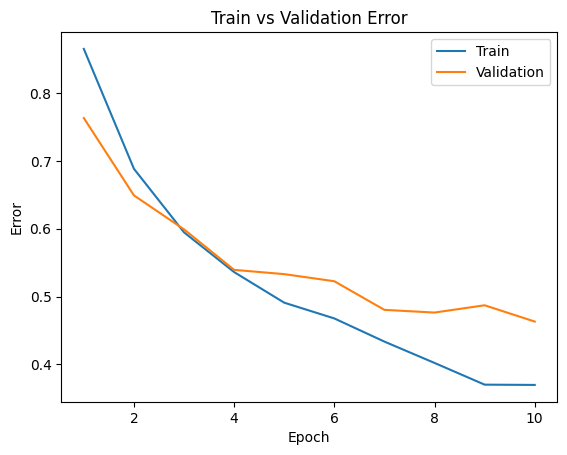

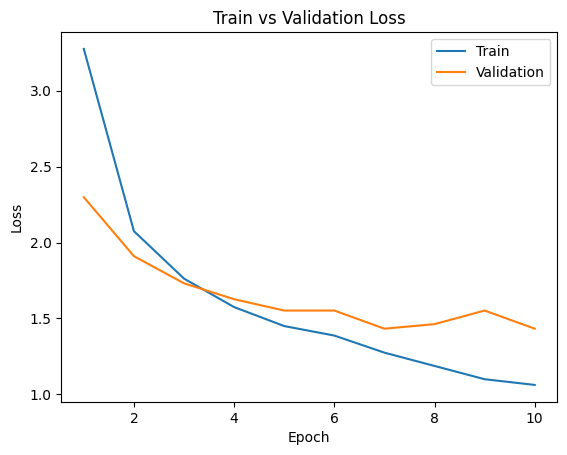

In [ ]:
model_path = get_model_name("TrashBot", batch_size=64, learning_rate=0.001, epoch=9)
plot_training_curve(model_path)

Actual class: Cardboard
Predicted class: Biological


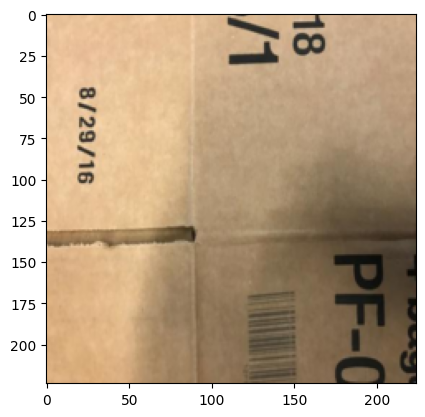

Actual class: Clothes
Predicted class: Biological


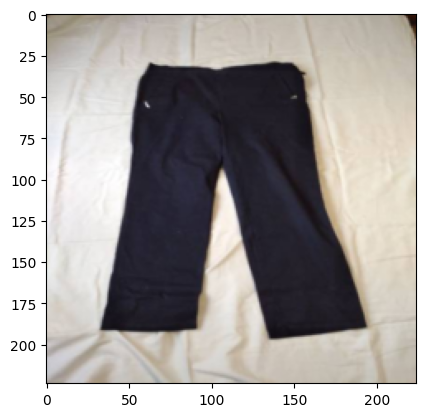

Actual class: White glass
Predicted class: Biological


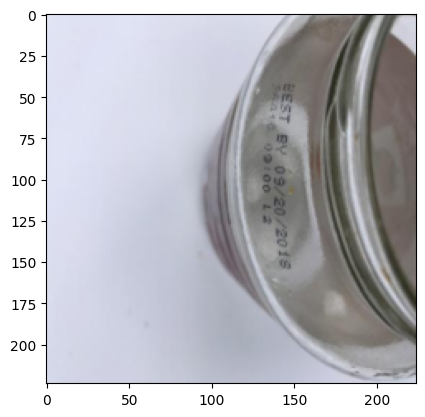

Actual class: Green glass
Predicted class: Biological


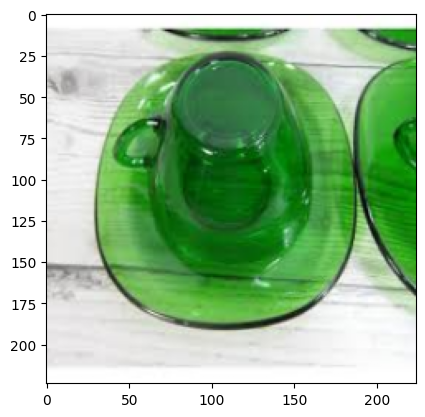

Actual class: Metal
Predicted class: Biological


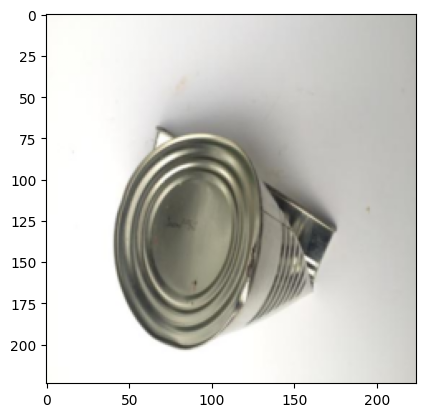

Actual class: Trash
Predicted class: Biological


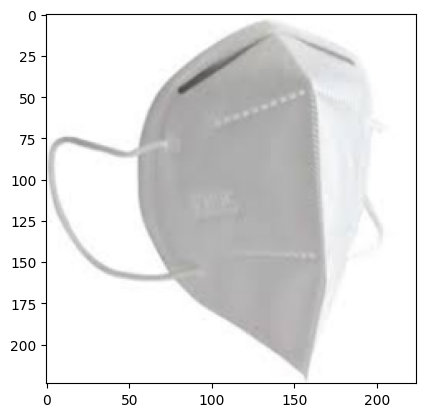

Actual class: Trash
Predicted class: Biological


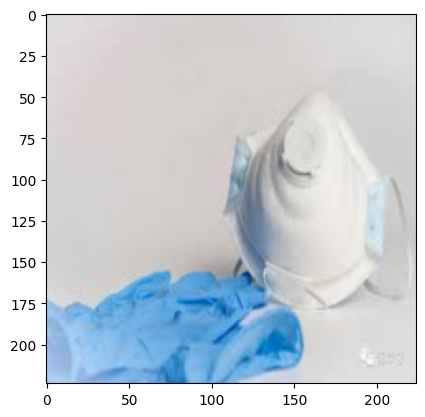

Actual class: Shoes
Predicted class: Biological


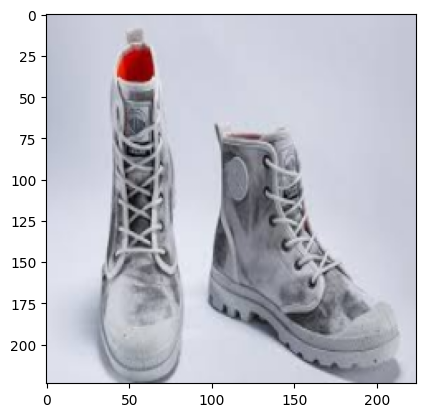

Actual class: Brown glass
Predicted class: Biological


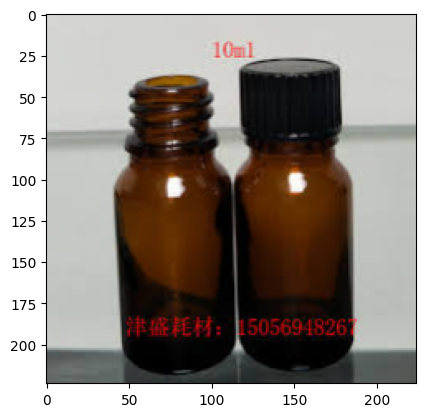

Actual class: Trash
Predicted class: Biological


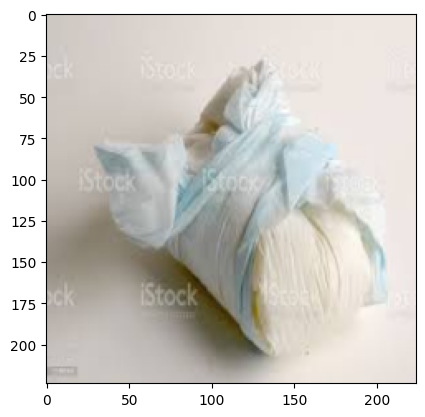

Actual class: Trash
Predicted class: Biological


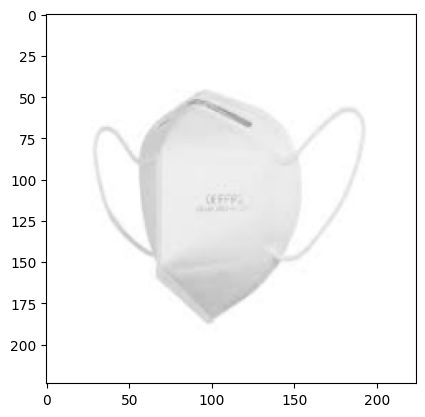

Actual class: Biological
Predicted class: Biological


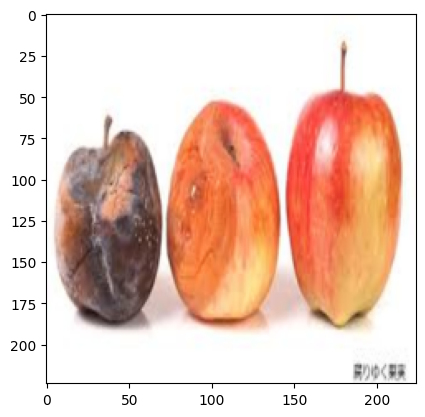

Actual class: Paper
Predicted class: Biological


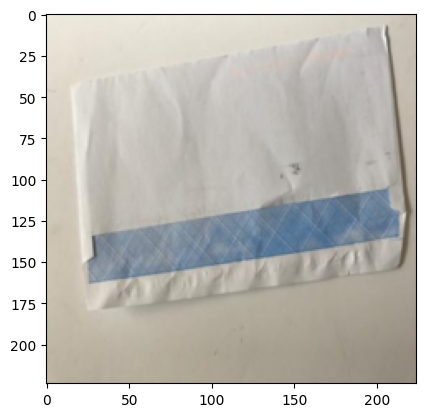

Actual class: Battery
Predicted class: Biological


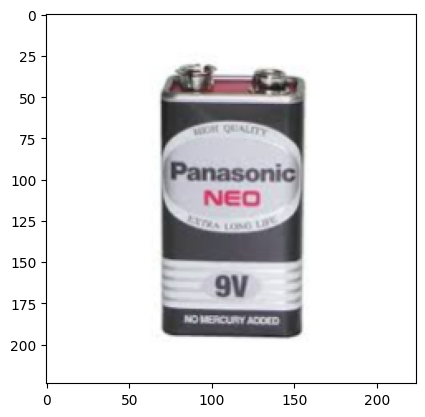

Actual class: Trash
Predicted class: Biological


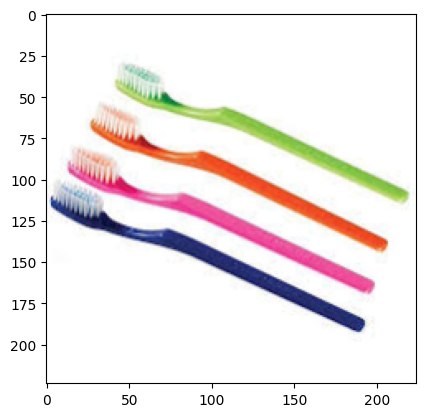

Actual class: Metal
Predicted class: Biological


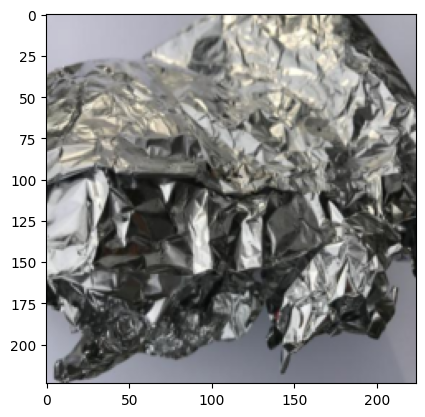

Actual class: Green glass
Predicted class: Biological


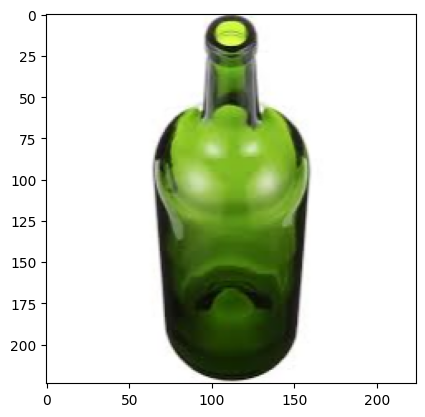

Actual class: Cardboard
Predicted class: Biological


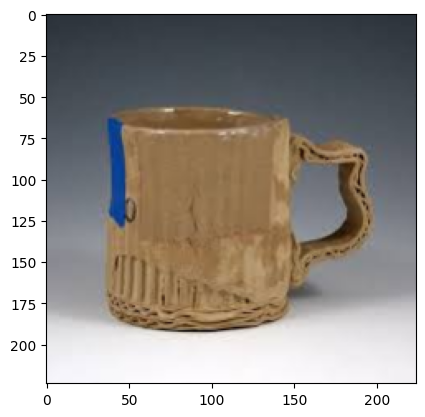

Actual class: Battery
Predicted class: Biological


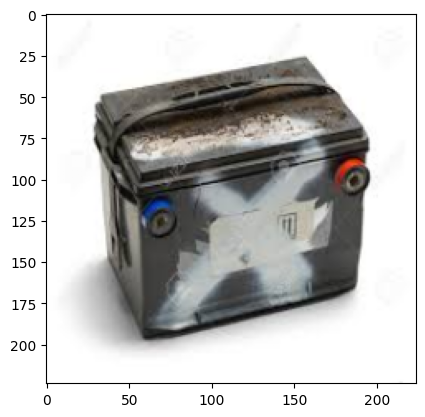

Actual class: Paper
Predicted class: Biological


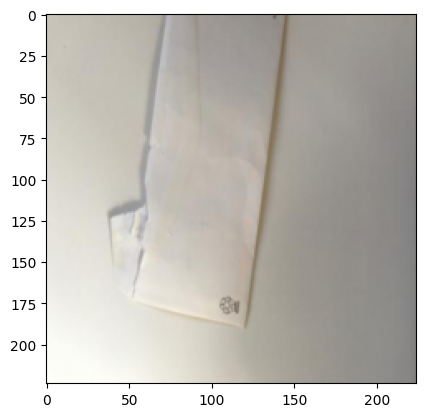

Actual class: Shoes
Predicted class: Biological


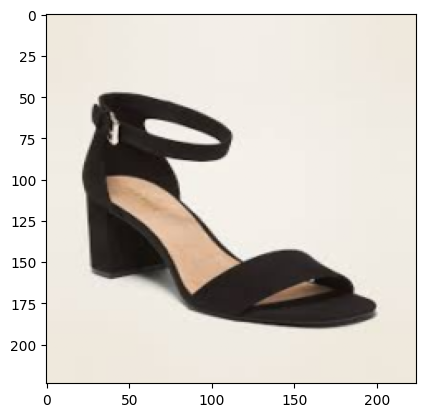

Actual class: Paper
Predicted class: Biological


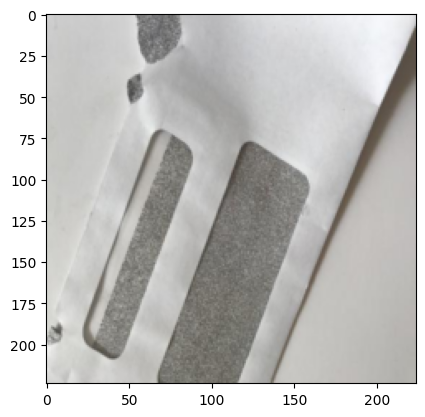

Actual class: Cardboard
Predicted class: Biological


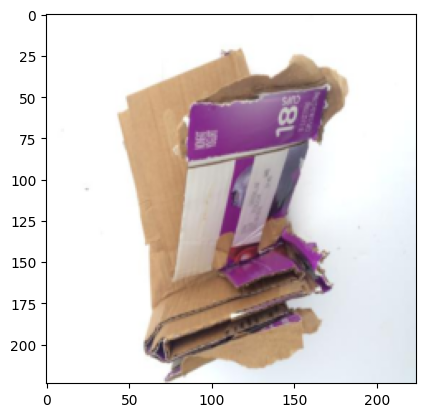

Actual class: White glass
Predicted class: Biological


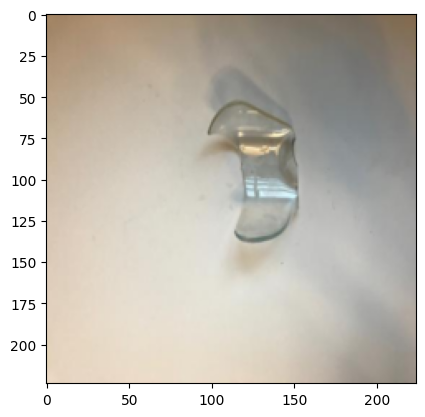

Actual class: Battery
Predicted class: Biological


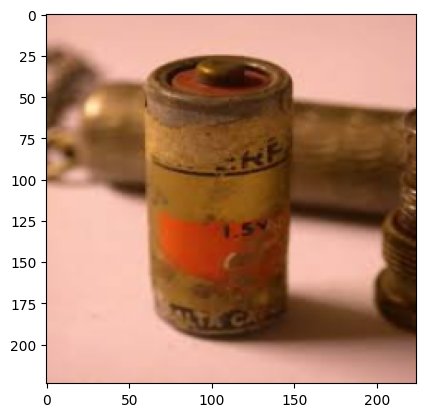

In [ ]:
def predict_single_image(net, dataloader):
    # Assuming the first image in the dataloader is used for prediction
    for images, labels in dataloader:

        label = labels[0].item()
        print("Actual class:", classNames[label])

        transform2 = transforms.Compose([
            transforms.Resize((224, 224)),
            # transforms.ToTensor(),
        ])

        for image in images:
            image = transform2(image)
            image = image.unsqueeze(0)
            if torch.cuda.is_available():
                image = image.cuda()

        if torch.cuda.is_available():
            images = images.cuda()

        # print("Size", images.size())

        net.eval()
        with torch.no_grad():
            output = net(images)
            # print("The size of output is", output.size())
            maxValue = max(output[0])
            for i in range(len(output[0])):
                if output[0][i] == maxValue:
                    print("Predicted class:", classNames[i])

        # Display the image

        cpuTensor = images[0].cpu()
        drawImage = cpuTensor.squeeze(0).numpy()

        drawImage = np.transpose(drawImage, (1, 2, 0))  # Change dimensions from CxHxW to HxWxC

        plt.imshow(drawImage)
        plt.show()

# Predict the output for a random image from the DataLoader
predicted_class = predict_single_image(trashy, train_loader)